@Archy

this notebook is for analysing the mobility data in target area (canary wharf)

In [6]:
import os, glob
from pathlib import Path

import duckdb
import pandas as pd
from tqdm import tqdm

In [11]:
# ✅ 改成你的数据根目录（包含 2025-03/0/part-*.gz 之类的结构）
DATA_ROOT = r"../data"     # 示例：Linux/mac 用 "../data"
# DATA_ROOT = r"C:\path\to\data"  # Windows 示例

# MONTH = "2025-03"
MONTHS = ["2025-03", "2025-04"]

# ✅ 临时目录：强烈建议放本地 SSD（Windows 示例）
TEMP_DIR = r"C:\Temp\duckdb_tmp"

# ✅ 线程数（8 通常够用）
THREADS = 8

# ✅ 内存限制（按你机器调，8GB / 16GB 都行）
MEMORY_LIMIT = "8GB"


In [9]:
def count_unique_users_by_day_duckdb_glob_safe(
    *,
    data_dirs_path: str,
    month: str,
    modes=None,
    threads: int = 8,
    temp_dir: str | None = None,
    memory_limit: str | None = "8GB",
    approx: bool = True,
    show_progress: bool = True,
):
    """
    Count daily unique users over ALL .gz TSV files under:
        data_dirs_path/month/**/**/*.gz

    Uses DuckDB read_csv with glob pattern (no giant file-list SQL).
    approx=True uses approx_count_distinct(user_id) for speed (great for diagnostics).
    """
    con = duckdb.connect(":memory:")
    con.execute(f"PRAGMA threads={int(threads)};")

    if show_progress:
        con.execute("PRAGMA enable_progress_bar=true;")
        con.execute("PRAGMA progress_bar_time=2000;")  # ms

    if temp_dir:
        Path(temp_dir).mkdir(parents=True, exist_ok=True)
        # escape backslashes for SQL on Windows
        temp_sql = str(temp_dir).replace("\\", "\\\\")
        con.execute(f"PRAGMA temp_directory='{temp_sql}';")

    if memory_limit:
        con.execute(f"PRAGMA memory_limit='{memory_limit}';")

    pattern = str(Path(data_dirs_path) / month / "**" / "*.gz")
    pattern_sql = pattern.replace("\\", "\\\\")  # Windows 安全

    if modes:
        modes_sql = "(" + ",".join([f"'{m}'" for m in modes]) + ")"
        mode_filter_sql = f"WHERE transport_mode IN {modes_sql}"
    else:
        mode_filter_sql = ""

    distinct_expr = "approx_count_distinct(user_id)" if approx else "COUNT(DISTINCT user_id)"

    sql = """
    SELECT
        date,
        {distinct_expr} AS unique_users
    FROM read_csv(
        '{pattern}',
        delim='\\t',
        header=false,
        columns={{
            'user_id': 'VARCHAR',
            'lat': 'VARCHAR',
            'lon': 'VARCHAR',
            'timestamp': 'VARCHAR',
            'date': 'VARCHAR',
            'h3_index': 'VARCHAR',
            'transport_mode': 'VARCHAR'
        }}
    )
    {mode_filter}
    GROUP BY date
    ORDER BY date
    """.format(
        distinct_expr=distinct_expr,
        pattern=pattern_sql,
        mode_filter=mode_filter_sql,
    )

    df = con.execute(sql).df()
    con.close()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    return df


In [10]:
df_all_approx = count_unique_users_by_day_duckdb_glob_safe(
    data_dirs_path=DATA_ROOT,
    month=MONTH,
    modes=None,         # all modes
    threads=THREADS,
    temp_dir=TEMP_DIR,
    memory_limit=MEMORY_LIMIT,
    approx=True,        # 先用近似，诊断足够快
    show_progress=True,
)

df_all_approx.head(), df_all_approx.tail(), df_all_approx.shape


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(        date  unique_users
 0 2025-03-01       8033811
 1 2025-03-02       7211059
 2 2025-03-03       8386520
 3 2025-03-04       7319668
 4 2025-03-05       6007832,
          date  unique_users
 26 2025-03-27       5353055
 27 2025-03-28       4280525
 28 2025-03-29       5312324
 29 2025-03-30       4555705
 30 2025-03-31       4889707,
 (31, 2))

In [12]:
def count_unique_users_by_day_duckdb_glob_multi(
    *,
    data_dirs_path: str,
    months: list[str],
    **kwargs,   # 透传 threads / temp_dir / approx 等
):
    dfs = []
    for m in months:
        df_m = count_unique_users_by_day_duckdb_glob_safe(
            data_dirs_path=data_dirs_path,
            month=m,
            **kwargs,
        )
        dfs.append(df_m)

    df = pd.concat(dfs, ignore_index=True)
    df["date"] = pd.to_datetime(df["date"])
    # 兜底：防止重复日期（如果有重叠）
    df = df.groupby("date", as_index=False)["unique_users"].max()
    df = df.sort_values("date").reset_index(drop=True)
    return df


In [13]:
df_all_approx = count_unique_users_by_day_duckdb_glob_multi(
    data_dirs_path=DATA_ROOT,
    months=["2025-03", "2025-04"],
    modes=None,
    threads=THREADS,
    temp_dir=TEMP_DIR,
    memory_limit=MEMORY_LIMIT,
    approx=True,
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [14]:
df_all_approx.head(), df_all_approx.tail(), df_all_approx.shape

(        date  unique_users
 0 2025-03-01       8033811
 1 2025-03-02       7211059
 2 2025-03-03       8386520
 3 2025-03-04       7319668
 4 2025-03-05       6007832,
          date  unique_users
 56 2025-04-26       6462502
 57 2025-04-27       5044843
 58 2025-04-28       5154747
 59 2025-04-29       5464134
 60 2025-04-30       4538499,
 (61, 2))

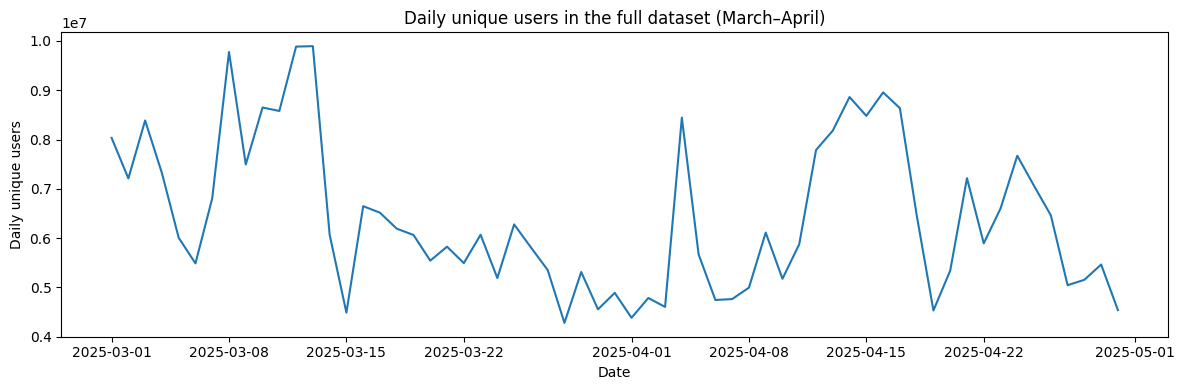

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# 保险起见，确保 date 是 datetime 且排序正确
df_plot = df_all_approx.copy()
df_plot["date"] = pd.to_datetime(df_plot["date"])
df_plot = df_plot.sort_values("date")

plt.figure(figsize=(12, 4))
plt.plot(df_plot["date"], df_plot["unique_users"])
plt.xlabel("Date")
plt.ylabel("Daily unique users")
plt.title("Daily unique users in the full dataset (March–April)")
plt.tight_layout()
plt.show()


In [16]:
# 确保 date 是 datetime
df_tmp = df_all_approx.copy()
df_tmp["date"] = pd.to_datetime(df_tmp["date"])

# 人数最多的一天
max_row = df_tmp.loc[df_tmp["unique_users"].idxmax()]

# 人数最少的一天
min_row = df_tmp.loc[df_tmp["unique_users"].idxmin()]

print("📈 Day with the MOST users")
print(f"Date: {max_row['date'].date()}")
print(f"Unique users: {int(max_row['unique_users']):,}")

print("\n📉 Day with the FEWEST users")
print(f"Date: {min_row['date'].date()}")
print(f"Unique users: {int(min_row['unique_users']):,}")


📈 Day with the MOST users
Date: 2025-03-13
Unique users: 9,893,349

📉 Day with the FEWEST users
Date: 2025-03-28
Unique users: 4,280,525
